# JobKB — Base de connaissances Occupations IT ↔ Compétences

In [ ]:
import sys, os, re, math
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Markdown, display

from src import config as C, common as K, hierarchy as H
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 170)

def load(p):
    return pd.DataFrame(K.read_all(p)) if os.path.isfile(p) else pd.DataFrame()
def nonempty(df, col):
    return 0 if (df.empty or col not in df) else int((df[col].fillna('').astype(str).str.strip() != '').sum())

occ  = load(C.OCCUPATIONS_CSV);          skl  = load(C.SKILLS_CSV)
uocc = load(C.UNIFIED_OCCUPATIONS_CSV);   uskl = load(C.UNIFIED_SKILLS_CSV)
hier = load(C.HIERARCHY_CSV);             rel  = load(C.OCC_SKILL_REL_CSV)
TAXO = list(C.TAXONOMY_SKILL_MARKERS)
real_occ = occ[occ.occupation_type != 'isco_group']
real_skl = skl[~skl.esco_skill_type.isin(TAXO)]
allc = pd.concat([uocc, uskl], ignore_index=True)
print(f"loaded  ·  {len(uocc)} unified occupations  ·  {len(uskl)} unified skills  ·  "
      f"{len(rel)} relations  ·  {len(hier)} hierarchy edges")

loaded  ·  292 unified occupations  ·  11136 unified skills  ·  34697 relations  ·  12769 hierarchy edges


## Partie 0 · Contexte & objectifs

**Le problème:** Le marché de l'emploi IT est décrit par de multiples référentiels publics hétérogènes qui ne partagent aucune table de correspondance, emploient des langues et des granularités différentes, et se recouvrent partiellement. Il manque une sorte de base unifiée qui relie *occupations* et *compétences* (hard/soft) et qui peut être exploitable pour des systèmes de recommandation.

**L'objectif:** Construire cette base avec un périmètre stricte (IT) et à travers un processus entièrement automatique (agentique) et évolutif.

In [ ]:
# Carte d'identité du KB
kpi = {
    'Occupations réelles': len(real_occ),
    'Groupes ISCO (squelette)': len(occ) - len(real_occ),
    'Compétences (hors nœuds de taxonomie)': len(real_skl),
    'Concepts unifiés — occupations': len(uocc),
    'Concepts unifiés — compétences': len(uskl),
    'Relations occupation→compétence': len(rel),
    'Arêtes de hiérarchie': len(hier),
    'Concepts ancrés à Wikidata (QID)': nonempty(allc, 'wikidata_qid'),
    'Labels EN / FR (concepts unifiés)': f"{nonempty(allc, 'primary_label_en')} / {nonempty(allc, 'primary_label_fr')}",
}
display(pd.Series(kpi, name='valeur').to_frame())
print('cohérence logique auto-certifiée à chaque build — détail en Partie 2 (consistency 13/13).')

,valeur
Occupations réelles,308
Groupes ISCO (squelette),24
Compétences (hors nœuds de taxonomie),12098
Concepts unifiés — occupations,292
Concepts unifiés — compétences,11136
Relations occupation→compétence,34697
Arêtes de hiérarchie,12769
Concepts ancrés à Wikidata (QID),1201
Labels EN / FR (concepts unifiés),11408 / 11041


cohérence logique auto-certifiée à chaque build — détail en Partie 2 (consistency 13/13).


## Partie 1 · Architecture & pipeline

`ingest → hierarchy → align → attach → merge → qa (quality assurance)`

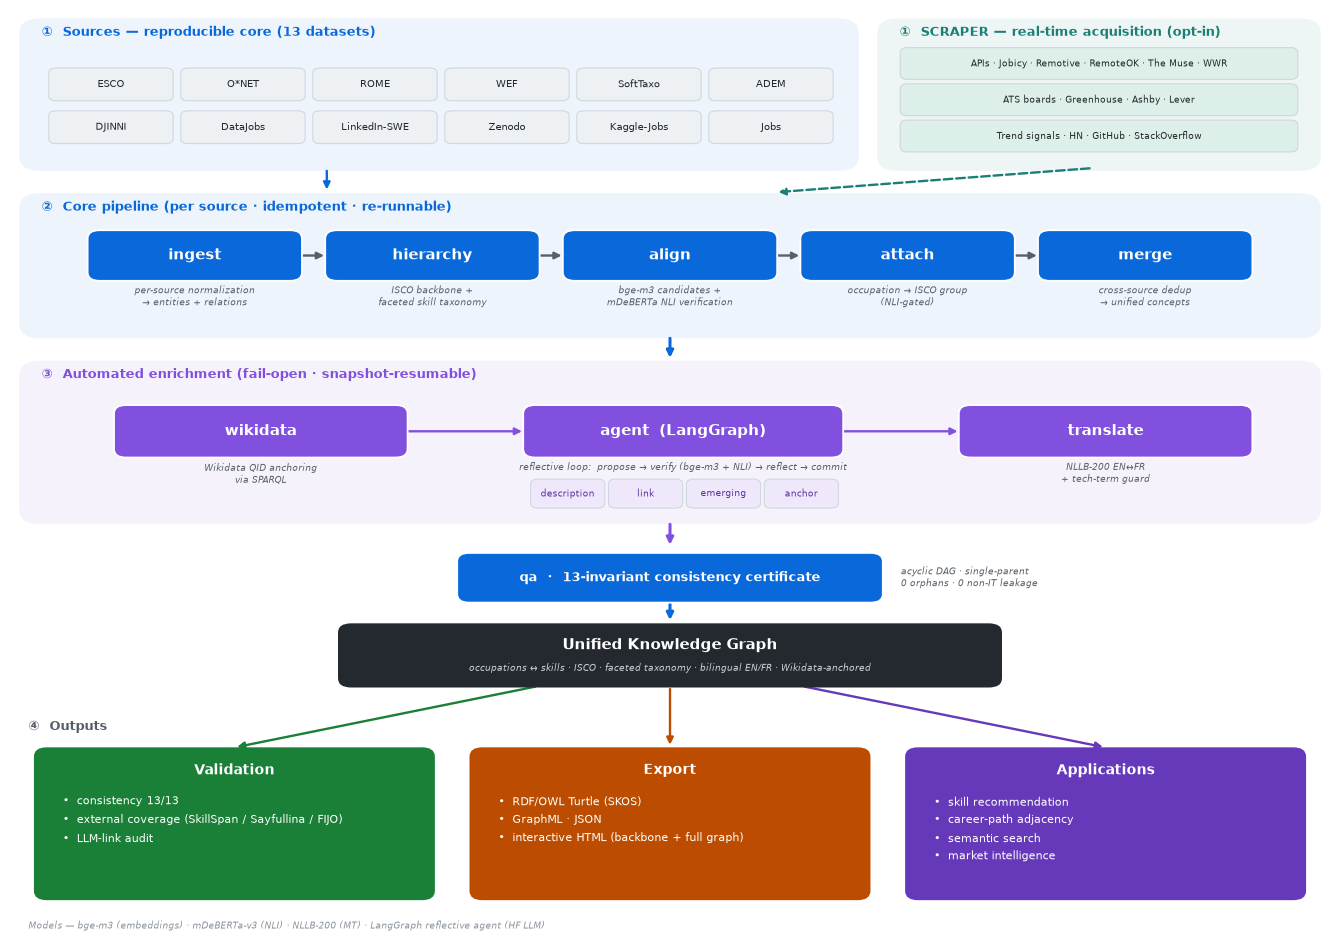

In [ ]:
# Detailed system architecture of JobKB
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(13.5, 9.6)); ax.axis('off')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
BLUE, PURPLE, TEAL = '#0969da', '#8250df', '#1a7f76'
GREEN, ORANGE, INDIGO = '#1a7f37', '#bc4c00', '#6639ba'

def band(x, y, w, h, fc, title=None, alpha=0.07):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.3,rounding_size=1.6',
                 fc=fc, ec=fc, alpha=alpha, lw=0, zorder=0))
    if title:
        ax.text(x + 1.4, y + h - 0.5, title, ha='left', va='top', fontsize=9, weight='bold', color=fc, zorder=4)

def box(x, y, w, h, text, fc, fs=9.5, tc='white', weight='bold', ec='white'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.12,rounding_size=0.9',
                 fc=fc, ec=ec, lw=1.3, zorder=3))
    if text:
        ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', color=tc, fontsize=fs, weight=weight, zorder=4)

def chip(x, y, w, h, text, fs=7.2, fc='#eef1f4', tc='#24292f'):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.06,rounding_size=0.55',
                 fc=fc, ec='#d0d7de', lw=0.8, zorder=3))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', color=tc, fontsize=fs, zorder=4)

def cap(x, y, text, color='#57606a', fs=6.5):
    ax.text(x, y, text, ha='center', va='top', fontsize=fs, color=color, style='italic', zorder=4)

def arr(x1, y1, x2, y2, color='#57606a', lw=1.7, ls='-'):
    ax.annotate('', (x2, y2), (x1, y1),
                arrowprops=dict(arrowstyle='-|>', lw=lw, color=color, linestyle=ls), zorder=1)

# ── (1) SOURCES ──────────────────────────────────────────────────────────────────
band(1, 83, 63, 15.8, BLUE, title='①  Sources — reproducible core (13 datasets)')
for i, name in enumerate(['ESCO', 'O*NET', 'ROME', 'WEF', 'SoftTaxo', 'ADEM',
                          'DJINNI', 'DataJobs', 'LinkedIn-SWE', 'Zenodo', 'Kaggle-Jobs', 'Jobs']):
    r, c = divmod(i, 6)
    chip(3 + c * 10.0, 90.3 - r * 4.6, 9.3, 3.4, name)
band(66, 83, 33, 15.8, TEAL, title='①  SCRAPER — real-time acquisition (opt-in)')
chip(67.5, 92.6, 30, 3.3, 'APIs · Jobicy · Remotive · RemoteOK · The Muse · WWR', fs=6.4, fc='#dcefe9')
chip(67.5, 88.7, 30, 3.3, 'ATS boards · Greenhouse · Ashby · Lever', fs=6.4, fc='#dcefe9')
chip(67.5, 84.8, 30, 3.3, 'Trend signals · HN · GitHub · StackOverflow', fs=6.4, fc='#dcefe9')
arr(24, 83, 24, 80.4, BLUE); arr(82, 83, 58, 80.4, TEAL, ls='--')

# ── (2) CORE PIPELINE ────────────────────────────────────────────────────────────
band(1, 65, 98, 15, BLUE, title='②  Core pipeline (per source · idempotent · re-runnable)')
core = [('ingest', 'per-source normalization\n→ entities + relations'),
        ('hierarchy', 'ISCO backbone +\nfaceted skill taxonomy'),
        ('align', 'bge-m3 candidates +\nmDeBERTa NLI verification'),
        ('attach', 'occupation → ISCO group\n(NLI-gated)'),
        ('merge', 'cross-source dedup\n→ unified concepts')]
xs, X, W, G, YS = [], 6.0, 16.0, 2.0, 71.0
for name, capt in core:
    box(X, YS, W, 5.2, name, BLUE, fs=10.5)
    cap(X + W / 2, YS - 0.5, capt)
    xs.append((X, X + W)); X += W + G
for i in range(len(xs) - 1):
    arr(xs[i][1], YS + 2.6, xs[i + 1][0], YS + 2.6)
arr(50, 65, 50, 62.3, BLUE, lw=2.2)

# ── (3) AUTOMATED ENRICHMENT ─────────────────────────────────────────────────────
band(1, 45, 98, 17, PURPLE,
     title='③  Automated enrichment (fail-open · snapshot-resumable)')
box(8, 52, 22, 5.4, 'wikidata', PURPLE, fs=10.5)
box(39, 52, 24, 5.4, 'agent  (LangGraph)', PURPLE, fs=10.5)
box(72, 52, 22, 5.4, 'translate', PURPLE, fs=10.5)
arr(30, 54.7, 39, 54.7, PURPLE); arr(63, 54.7, 72, 54.7, PURPLE)
cap(19, 51.4, 'Wikidata QID anchoring\nvia SPARQL')
cap(51, 51.4, 'reflective loop:  propose → verify (bge-m3 + NLI) → reflect → commit')
cap(83, 51.4, 'NLLB-200 EN↔FR\n+ tech-term guard')
for i, wname in enumerate(['description', 'link', 'emerging', 'anchor']):
    chip(39.5 + i * 5.9, 46.5, 5.5, 3.0, wname, fs=6.5, fc='#efe8fb', tc='#5a32a3')
arr(50, 45, 50, 42.2, PURPLE, lw=2.2)

# ── qa gate + kb/ ────────────────────────────────────────────────────────────────
box(34, 36.4, 32, 5.1, 'qa  ·  13-invariant consistency certificate', BLUE, fs=9.5)
ax.text(67.5, 39.0, 'acyclic DAG · single-parent\n0 orphans · 0 non-IT leakage',
        ha='left', va='center', fontsize=6.3, color='#57606a', style='italic', zorder=4)
arr(50, 36.4, 50, 34.1, BLUE, lw=2.2)
ax.add_patch(FancyBboxPatch((25, 27.3), 50, 6.6, boxstyle='round,pad=0.15,rounding_size=1.0',
             fc='#24292f', ec='#24292f', lw=0, zorder=3))
ax.text(50, 31.7, 'Unified Knowledge Graph',
        ha='center', va='center', color='white', fontsize=11, weight='bold', zorder=4)
ax.text(50, 29.25, 'occupations ↔ skills · ISCO · faceted taxonomy · bilingual EN/FR · Wikidata-anchored',
        ha='center', va='center', color='#c9d1d9', fontsize=6.7, style='italic', zorder=4)

# ── (4) OUTPUTS ──────────────────────────────────────────────────────────────────
def outbox(x, color, title, lines):
    box(x, 4.5, 30, 16, '', color, ec=color)
    ax.text(x + 15, 19.0, title, ha='center', va='top', color='white', fontsize=10, weight='bold', zorder=5)
    ax.text(x + 2.0, 15.9, '\n'.join('•  ' + l for l in lines), ha='left', va='top',
            color='white', fontsize=7.7, zorder=5, linespacing=1.7)
ax.text(1.4, 23.6, '④  Outputs', ha='left', va='top', fontsize=9, weight='bold', color='#57606a')
outbox(2, GREEN, 'Validation',
       ['consistency 13/13', 'external coverage (SkillSpan / Sayfullina / FIJO)', 'LLM-link audit'])
outbox(35, ORANGE, 'Export',
       ['RDF/OWL Turtle (SKOS)', 'GraphML · JSON', 'interactive HTML (backbone + full graph)'])
outbox(68, INDIGO, 'Applications',
       ['skill recommendation', 'career-path adjacency', 'semantic search', 'market intelligence'])
arr(40, 27.3, 17, 20.7, GREEN); arr(50, 27.3, 50, 20.7, ORANGE); arr(60, 27.3, 83, 20.7, INDIGO)

ax.text(1.4, 1, 'Models — bge-m3 (embeddings) · mDeBERTa-v3 (NLI) · NLLB-200 (MT) · LangGraph reflective agent (HF LLM)',
        ha='left', va='bottom', fontsize=6.4, color='#8b949e', style='italic', zorder=4)

plt.tight_layout(); plt.show()


In [ ]:
# Sources récapitulées (rôle + apport chiffré)
occ_by = occ[occ.occupation_type != 'isco_group'].source.value_counts()
skl_by = real_skl.source.value_counts()
rel_by = rel.source.value_counts()
srcs = sorted(set(occ_by.index) | set(skl_by.index) | set(rel_by.index))
sdf = pd.DataFrame([{'source': s, 'occupations': int(occ_by.get(s, 0)),
                     'skills': int(skl_by.get(s, 0)), 'relations': int(rel_by.get(s, 0))}
                    for s in srcs]).sort_values(['occupations', 'skills', 'relations'], ascending=False)
print(f'{len(srcs)} sources contribuent au KB  (occupations / compétences / relations) :')
display(sdf.reset_index(drop=True))

22 sources contribuent au KB  (occupations / compétences / relations) :


,source,occupations,skills,relations
0,ESCO,110,1894,6613
1,ROME,93,2052,5146
2,SCRAPER,52,11,1577
3,ONET,32,1493,6589
4,NOC,15,0,0
5,EMERGING,6,0,0
6,LIGHTCAST,0,5243,0
7,KAGGLE,0,528,0
8,CSO,0,527,0
9,SFIA,0,95,0


## Partie 2 · Intégrité & cohérence logique

In [ ]:
from src import pipeline
qa = pipeline.qa()


=== QA ===
occupations: 332 (308 real, 24 ISCO groups)
skills: 12098 (+34 taxonomy nodes)  |  hierarchy edges: 12769  |  dangling: 0
skill taxonomy: 2 types / 10 domains / 22 categories  |  occupations linked to a functional domain: 308/308
EN label coverage (real occ): 215/308
occupation orphans (no hierarchy parent): 0
low-confidence ISCO attachments (review): 11
skills not placed in ontology: 0
non-IT ISCO group leakage: 0
relevance gate — blocked: 6 (non-IT 5, malformed 1); borderline-kept: 3
occupation-skill relations: 34697 (demand: 9811 — ADEM 1528, DATAJOBS 1275, DJINNI 2281, JOBS 1545, KAGGLE_JOBS 166, LINKEDIN_SWE 898, SCRAPER 1577, ZENODO 541)  |  dangling refs: 0
wikidata anchors: 1209 (1164 skills, 37 occupations, 8 domains; 1044 high-confidence)
wikidata in-graph: 1164 skills + 37 occupations carry a QID; 1141 carry a Wikidata description  |  dangling anchors: 0
descriptions: 11303/11428 concepts (by source: {'source': 2357, 'llm': 7955, 'wikidata': 991})  |  hard_soft: 

In [ ]:
# Les indicateurs de consistence
from src.validation import consistency
res = consistency.check()
cdf = pd.DataFrame(res, columns=['invariant', 'pass', 'detail'])
display(cdf)
assert bool(cdf['pass'].all()), "LOGICAL CONSISTENCY FAILED"
print(f"consistency: {int(cdf['pass'].sum())}/{len(cdf)} invariants PASS")

,invariant,pass,detail
0,hierarchy: no dangling edges,True,0 dangling
1,hierarchy: no self-loops,True,0 self-loops
2,hierarchy: acyclic (DAG),True,
3,skills: exactly one category parent,True,"0 multi-parent, 0 unplaced"
4,occupations: one backbone + one domain parent,True,"0 bad backbone, 0 bad facet"
5,"ISCO backbone: single root, all reach it",True,"1 roots, 0 unreachable"
6,ISCO: no non-IT group leakage,True,0 leaked groups
7,no skill->skill hierarchy edges,True,0 skill->skill edges
8,skills: hard_soft matches taxonomy,True,"0 mismatched, 0 empty"
9,relations: endpoints correctly typed,True,"0 bad occ, 0 bad skill endpoints"


consistency: 13/13 invariants PASS


## Partie 3 · JobKB en chiffres

In [7]:
dash = {
    'unified occupations': len(uocc),
    'unified skills': len(uskl),
    'occupation–skill relations': len(rel),
    'hierarchy edges': len(hier),
    'concepts with a description': nonempty(allc, 'description'),
    'primary label EN': nonempty(allc, 'primary_label_en'),
    'primary label FR': nonempty(allc, 'primary_label_fr'),
    'Wikidata-anchored concepts': nonempty(allc, 'wikidata_qid'),
    'skills with hard/soft set': f"{nonempty(uskl, 'hard_soft')}/{len(uskl)}",
}
display(pd.Series(dash, name='count').to_frame())
by_src = Counter(r for r in allc[allc.description.fillna('') != ''].get('description_source', []))
print('descriptions by source:', dict(by_src))

,count
unified occupations,292
unified skills,11136
occupation–skill relations,34697
hierarchy edges,12769
concepts with a description,11303
primary label EN,11408
primary label FR,11041
Wikidata-anchored concepts,1201
skills with hard/soft set,11136/11136


descriptions by source: {'source': 2357, 'llm': 7955, 'wikidata': 991}


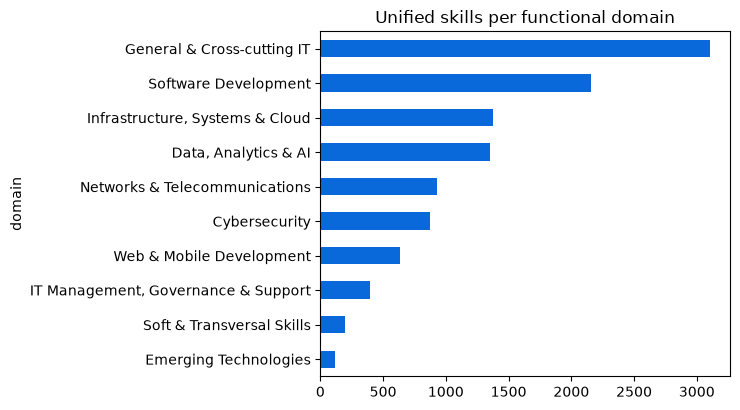

In [8]:
def skill_domain(sub):
    cat = H.CATEGORIES.get(sub)
    dom = H.DOMAINS.get(cat[0]) if cat else None
    return dom[1] if dom else 'other'
uskl = uskl.copy(); uskl['domain'] = uskl.it_subtype.map(skill_domain)
counts = uskl['domain'].value_counts()
ax = counts.plot.barh(figsize=(7.5, 4.2), color='#0969da')
ax.set_title('Unified skills per functional domain'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Partie 4 · Taxonomie

L'ontologie est facettée autour d'une couche de domaines fonctionnels partagée. Les compétences suivent `compétence → catégorie (22) → domaine (10) → type (hard/soft)`

In [9]:
tx = skl[skl.esco_skill_type.isin(TAXO)]
print('taxonomy tiers:', dict(tx.esco_skill_type.value_counts()))
facet = hier[(hier.entity_kind == 'occupation') & (hier.relation_type == 'in_domain')]
print(f'occupation→domain facet coverage: {facet.child_entity_id.nunique()}/{len(real_occ)}')
print('hierarchy relation types:', dict(hier.relation_type.value_counts()))

taxonomy tiers: {'skill_category': np.int64(22), 'skill_domain': np.int64(10), 'skill_type': np.int64(2)}
occupation→domain facet coverage: 308/308
hierarchy relation types: {'broader_than': np.int64(12461), 'in_domain': np.int64(308)}


## Partie 5 · Intégration

In [10]:
def n_members(s):
    return s.fillna('').apply(lambda v: len([x for x in v.split(' | ') if x]))
uskl['n_members'] = n_members(uskl.member_entity_ids)
uocc2 = uocc.copy(); uocc2['n_members'] = n_members(uocc2.member_entity_ids)
print(f"multi-source unified skills: {(uskl.n_members > 1).sum()}  ·  "
      f"multi-source unified occupations: {(uocc2.n_members > 1).sum()}")
display(uskl[uskl.n_members > 1].nlargest(8, 'n_members')[['primary_label_en', 'sources', 'n_members']])

multi-source unified skills: 710  ·  multi-source unified occupations: 13


,primary_label_en,sources,n_members
893,Machine Learning,CSO | ESCO | KAGGLE | LIGHTCAST | ROME | SFIA,6
2189,Microsoft Windows,CSO | DATAJOBS | KAGGLE | LIGHTCAST | ONET | Z...,6
4513,Virtualization,KAGGLE | LIGHTCAST | ROME,6
547,Database Management Systems,ESCO | LIGHTCAST | ONET | ROME,5
996,Ruby,ESCO | KAGGLE | LIGHTCAST | ONET | ROME,5
1179,Blockchain,ESCO | KAGGLE | LIGHTCAST | ROME,5
1457,Jenkins,DATAJOBS | ESCO | KAGGLE | LIGHTCAST | ZENODO,5
1749,MySQL,ESCO | KAGGLE | LIGHTCAST | ONET | ROME,5


## Partie 6 · Relations occupation ↔ compétence

In [11]:
print('relation types:', dict(rel.relation_type.value_counts()))
dem = rel[rel.relation_type == 'demand'].copy()
print('demand by source:', dict(dem.source.value_counts()))
lbl = dict(zip(skl.entity_id, skl.pref_label_en)); olbl = dict(zip(occ.entity_id, occ.pref_label_en))
top = dem.occupation_entity_id.value_counts().index[0]
print('\nsample — most-demanded skills for:', olbl.get(top, top))
s = dem[dem.occupation_entity_id == top].copy()
s['skill'] = s.skill_entity_id.map(lbl); s['weight'] = pd.to_numeric(s.weight, errors='coerce')
display(s.dropna(subset=['skill']).nlargest(10, 'weight')[['skill', 'weight', 'source']])

relation types: {'essential': np.int64(14288), 'demand': np.int64(9811), 'transversal': np.int64(6500), 'optional': np.int64(4060), 'llm_inferred': np.int64(38)}
demand by source: {'DJINNI': np.int64(2281), 'SCRAPER': np.int64(1577), 'JOBS': np.int64(1545), 'ADEM': np.int64(1528), 'DATAJOBS': np.int64(1275), 'LINKEDIN_SWE': np.int64(898), 'ZENODO': np.int64(541), 'KAGGLE_JOBS': np.int64(166)}

sample — most-demanded skills for: software developer


,skill,weight,source
29759,JavaScript (Programming Language),21092.0,DJINNI
28092,Python (computer programming),13749.0,DATAJOBS
29771,Docker (Software),13059.0,DJINNI
29757,TypeScript,12294.0,DJINNI
29830,Software Development,11585.0,DJINNI
29749,Java (Programming Language),11302.0,DJINNI
29848,Front End (Software Engineering),11269.0,DJINNI
28071,SQL,11078.0,DATAJOBS
29756,Python (Programming Language),9676.0,DJINNI
29742,Microservices,9469.0,DJINNI


## Partie 7 · Extensibilité & Web-scraping

Toute source peut s'ajouter / se retirer sans reconstruction (`--add` / `--remove`). 

Pour suivre le marché IT qui évolue vite, une couche d'acquisition web multi-sources (`SCRAPER`) alimente le KB quasi en temps réel :

- APIs d'emploi sans clé
- Tableaux ATS publics
- Signaux de tendance (technologies émergentes).

Chaque source passe la même logique d'acceptation : filtrage IT, extraction hybride (tags + dictionnaire + NER de compétences), passerelle de pertinence, et une demande pondérée par la fraîcheur. Un métier n'est créé que s'il récurre, se termine par une tête de métier et est associé à des compétences IT, sinon il est résolu vers une occupation existante.

*Démonstration hors-ligne*

In [ ]:
# Démonstration de la logique d'acceptation SCRAPER sur l'échantillon embarqué.
import csv
from src.sources.scraper import ScraperSource, _clean_title, _ROLE_HEAD
scr = ScraperSource(); scr._nlp = False          # NER neuronal désactivé

# 1) nettoyage des intitulés : suffixes d'équipe, séniorité, genre retirés ... tronqué à la tête de métier
print('nettoyage des intitulés :')
for t in ['Machine Learning Engineer, Relevance & Personalization', 'Senior Data Engineer (CDI) - Paris',
          'Staff Backend Engineer (Remote)', 'Manager, Solutions Architecture']:
    print(f'   {t[:48]:48s} -> {_clean_title(t)!r}')

sample = os.path.join(C.SCRAPED_DIR, 'fr', 'hellowork.sample.csv')
docs = list(csv.DictReader(open(sample, encoding='utf-8', newline='')))
print(f'\néchantillon : {len(docs)} offres')

# 2) même logique que `--add SCRAPER` : résoudre vers l'existant / créer un métier émergent / écarter
freq, existing, skilled, seen, roles = Counter(), {}, set(), {}, {}
for d in docs:
    res = scr.extract(d); oc = res['occupation']
    if not oc:
        continue
    k = oc['key']; freq[k] += 1; roles[k] = oc['label']
    if oc['existing_id']:
        existing[k] = oc['existing_id']
    if res['skills']:
        skilled.add(k); seen.setdefault(k, set()).update(x['label'] for x in res['skills'])

scr_rows = []
for k, n in freq.most_common():
    if k in existing:
        decision = 'résolu → occupation existante (demande)'
    elif n >= C.SCRAPER_MIN_OCC_FREQ and k in skilled and _ROLE_HEAD.search(roles[k]) and len(roles[k].split()) >= 2:
        decision = 'CRÉE un métier émergent'
    else:
        decision = 'écarté (pas de signal IT / trop rare)'
    scr_rows.append({'intitulé': roles[k], 'offres': n, 'décision': decision,
                     'compétences (top)': ', '.join(sorted(seen.get(k, []))[:6]) or '—'})
display(pd.DataFrame(scr_rows))

mints = [x['intitulé'] for x in scr_rows if x['décision'].startswith('CRÉE')]
drops = [x['intitulé'] for x in scr_rows if x['décision'].startswith('écarté')]
print(f'métiers émergents créés : {mints}')
print(f'écartés (intitulés non-IT, sans compétence IT) : {drops}')
assert mints, 'au moins un métier émergent attendu'
assert all(K.normalize_label(x) in ('chef de rang', 'boulanger') for x in drops), 'écart inattendu'
print("\ningestion réelle → `python run_pipeline.py --scrape all` puis `--add SCRAPER` "
      "(tags + NER + passerelle de pertinence + attach ISCO + merge ; qa reste 13/13).")

nettoyage des intitulés :
   Machine Learning Engineer, Relevance & Personali -> 'Machine Learning Engineer'
   Senior Data Engineer (CDI) - Paris               -> 'Data Engineer'
   Staff Backend Engineer (Remote)                  -> 'Backend Engineer'
   Manager, Solutions Architecture                  -> 'Manager'

échantillon : 14 offres


,intitulé,offres,décision,compétences (top)
0,prompt engineer,3,résolu → occupation existante (demande),"aws, docker, git, hugging face, kubernetes, la..."
1,platform engineer,2,CRÉE un métier émergent,"ansible, aws, docker, go, kubernetes, terraform"
2,ai engineer,2,CRÉE un métier émergent,"deep learning, docker, machine learning, pytho..."
3,data scientist,2,résolu → occupation existante (demande),"aws, deep learning, machine learning, pandas, ..."
4,developpeur,2,résolu → occupation existante (demande),"aws, docker, javascript, node.js, postgresql, ..."
5,chef de rang,2,écarté (pas de signal IT / trop rare),—
6,boulanger,1,écarté (pas de signal IT / trop rare),—


métiers émergents créés : ['platform engineer', 'ai engineer']
écartés (intitulés non-IT, sans compétence IT) : ['chef de rang', 'boulanger']

ingestion réelle → `python run_pipeline.py --scrape all` puis `--add SCRAPER` (tags + NER + passerelle de pertinence + attach ISCO + merge ; qa reste 13/13).


### Acquisition réelle multi-sources en direct

Ce bloc interroge l'Internet via les adaptateurs suivants: une **API d'emploi** (Jobicy), le feed **RemoteOK**, un **tableau ATS public** (Greenhouse) et un **signal de tendance** (GitHub). Il exécute ensuite l'extraction sur les éléments fraîchement récupérés.

In [ ]:
# Récupération réseau réelle via plusieurs adaptateurs, puis extraction.
from src import scrape
results = []
for adapter, n in [('jobicy', 4), ('remoteok', 3), ('ats', 4), ('github', 3)]:
    try:
        for d in scrape.fetch_live(adapter, limit=n):     # robots-vérifié, fail-open
            results.append((d, scr.extract(d)))           
    except Exception as e:                          
        print(f'  [{adapter}] erreur réseau : {type(e).__name__}')

if not results:
    print('⚠  sources en direct injoignables (hors-ligne) — voir la démo hors-ligne ci-dessus.')
else:
    srcs = sorted({d['site'] for d, _ in results})
    print(f'{len(results)} éléments récupérés EN DIRECT depuis : {srcs}\n')
    rows = []
    for d, r in results:
        tech = sorted({x['label'] for x in r['skills']})
        rows.append({'source': d['site'], 'offre / dépôt': (d['title'] or d['company'])[:34],
                     'métier nettoyé': (r['occupation']['label'] if r['occupation'] else '—'),
                     'compétences (extraites en direct)': ', '.join(tech[:6]) or '—'})
    display(pd.DataFrame(rows))
    n_sk = sum(1 for _, r in results if r['skills'])
    print(f'\n{n_sk}/{len(results)} éléments → ≥1 compétence IT extraite '
          '(crawl+parse+extract réel : APIs d\'emploi, tableaux ATS, signaux de tendance — sans fixture).')
    assert n_sk >= 1, 'aucune compétence extraite des sources en direct'
    print('rafraîchissement temps-réel : `python run_pipeline.py --refresh-scraper` (crawl all + ré-ingestion).')

  [ats] greenhouse:stripe -> 40 IT postings
14 éléments récupérés EN DIRECT depuis : ['ats:greenhouse', 'github', 'jobicy', 'remoteok']



,source,offre / dépôt,métier nettoyé,compétences (extraites en direct)
0,jobicy,Staff Software Engineer- Growth Pe,software engineer,"data integrity, data pipelines, data science, ..."
1,jobicy,Software Development Engineer in T,software development engineer,"aws, cypress, devops, jenkins, mongo, mysql"
2,jobicy,Devices & IOT Field Engineering Ma,devices & iot field,"connected devices, consumer electronics, data ..."
3,jobicy,"Senior Machine Learning Engineer,",machine learning engineer,"airflow, anomaly detection, artificial intelli..."
4,remoteok,Java Developer,java developer,"argocd, backend, cloud, containerization, dock..."
5,remoteok,Architectural Designer,architectural designer,"cad software, collaborative work, developing d..."
6,remoteok,The quest build a better AI tutor,the quest build a,"data annotation, teaching"
7,ats:greenhouse,Accounting AI Solutions Lead,accounting ai solutions,"ai applications, artificial intelligence, data..."
8,ats:greenhouse,AI Engineer,ai engineer,"aws, clean code, cloud infrastructure, codebas..."
9,ats:greenhouse,"AI Product Manager, Professional S",ai product manager,"agentic ai, executable, foundation, internet, ..."



14/14 éléments → ≥1 compétence IT extraite (crawl+parse+extract réel : APIs d'emploi, tableaux ATS, signaux de tendance — sans fixture).
rafraîchissement temps-réel : `python run_pipeline.py --refresh-scraper` (crawl all + ré-ingestion).


## Partie 8 · Enrichissement (agentique/LLM · Wikidata · Bilingue)

Après la fusion, le pipeline enrichit automatiquement la base :
- **Wikidata** : ancrage des concepts à des QID stables + descriptions/alias autoritaires.
- **Agent LangGraph** : un contrôleur dépêche des workers réflexifs (proposer → vérifier → réfléchir → valider) qui génèrent des descriptions et infèrent des liens occupation→compétence, validés par NLI.
- **Bilingue** : complétion des labels EN/FR manquants (labels Wikidata + traduction NLLB validée par similarité interlingue).

In [14]:
print('Wikidata-anchored concepts:', nonempty(allc, 'wikidata_qid'))
display(uskl[uskl.wikidata_qid.fillna('') != ''][['primary_label_en', 'wikidata_qid', 'wikidata_description']].head(6))
print('LLM/agentic descriptions:', int((allc.get('description_source', pd.Series(dtype=str)) == 'llm').sum()))
print('llm_inferred links:', int((rel.relation_type == 'llm_inferred').sum()))
print(f"bilingual coverage — EN {nonempty(allc,'primary_label_en')}/{len(allc)}  ·  "
      f"FR {nonempty(allc,'primary_label_fr')}/{len(allc)}")

Wikidata-anchored concepts: 1201


,primary_label_en,wikidata_qid,wikidata_description
1,musical theory,Q193544,study of the theoretical aspects of music and ...
14,GameSalad,Q4039237,authoring tool
17,Chef,Q24479,configuration management tool
19,sensors,P9192,notable sensors in the electronic device
57,green computing,Q19605512,eco-design of information and communication te...
58,Havok Vision,Q4040458,multi-platform 3D software engine


LLM/agentic descriptions: 7955
llm_inferred links: 38
bilingual coverage — EN 11408/11428  ·  FR 11041/11428


## Partie 9 · Validation

Trois pistes de validation (en utilisant les modèles `bge-m3` + `mDeBERTa`):
1. **Certificat de cohérence** : les 13 invariants logiques.
2. **Couverture externe** : la base est confrontée à trois corpus experts annotés (SkillSpan, Sayfullina, FIJO), en correspondance exacte et sémantique.
3. **Audit des liens LLM** : re-valide les liens `llm_inferred` (NLI + corroboration par la demande), confirmant qu'ils sont le contenu le moins corroboré et doivent rester un type séparé.

In [15]:
from src import validation
_ = validation.run(('consistency', 'coverage', 'llm'))
cov = os.path.join(C.VALIDATION_OUT_DIR, 'coverage_summary.csv')
if os.path.isfile(cov):
    print('External gold coverage:'); display(pd.read_csv(cov))
rep = os.path.join(C.VALIDATION_OUT_DIR, 'report.md')
if os.path.isfile(rep):
    display(Markdown(open(rep, encoding='utf-8').read()))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[EMBED] model = BAAI/bge-m3 (mode=st)
[VALIDATE] consistency: 13/13 invariants PASS
[VALIDATE] coverage skillspan: 6423 unique gold mentions
[VALIDATE] coverage sayfullina: 1140 unique gold mentions
[VALIDATE] coverage fijo: 692 unique gold mentions
[VALIDATE] normalization: 22/108 clusters collapse to one node (20.4%)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[VALIDATE] llm links: NLI 38/38, demand-corroborated 16/38; descriptions NLI 7955/7955
[VALIDATE] report written to d:\JobKB-final\validation\report.md
External gold coverage:


,dataset,layer,subset,gold,exact_n,exact_pct,semantic_n,semantic_pct,covered_pct
0,skillspan,ALL,NaN,6423,707,11.0,3676,57.2,57.7
1,skillspan,knowledge,house,928,72,7.8,364,39.2,39.8
2,skillspan,knowledge,tech,1840,503,27.3,1336,72.6,73.4
3,skillspan,skill,house,1771,63,3.6,884,49.9,50.1
4,skillspan,skill,tech,1884,69,3.7,1092,58.0,58.2
5,sayfullina,ALL,NaN,1140,81,7.1,707,62.0,62.5
6,sayfullina,skill,NaN,1140,81,7.1,707,62.0,62.5
7,fijo,ALL,NaN,692,2,0.3,242,35.0,35.0
8,fijo,skill,NaN,692,2,0.3,242,35.0,35.0


# JobKB validation report
_generated 2026-08-07T11:55:38+00:00_

## 1. Logical consistency — 13/13 invariants PASS
- PASS — hierarchy: no dangling edges (0 dangling)
- PASS — hierarchy: no self-loops (0 self-loops)
- PASS — hierarchy: acyclic (DAG)
- PASS — skills: exactly one category parent (0 multi-parent, 0 unplaced)
- PASS — occupations: one backbone + one domain parent (0 bad backbone, 0 bad facet)
- PASS — ISCO backbone: single root, all reach it (1 roots, 0 unreachable)
- PASS — ISCO: no non-IT group leakage (0 leaked groups)
- PASS — no skill->skill hierarchy edges (0 skill->skill edges)
- PASS — skills: hard_soft matches taxonomy (0 mismatched, 0 empty)
- PASS — relations: endpoints correctly typed (0 bad occ, 0 bad skill endpoints)
- PASS — unified: members valid & unshared (0 empty, 0 missing, 0 shared)
- PASS — ids: entity_id & unified_id unique (0 dup entity_id, 0 dup unified_id)
- PASS — relations: no identical duplicate rows (0 identical dups; 34697 rows / 33439 unique (occ,skill,type))

## 2. External coverage benchmark (KB skill-vocabulary recall vs expert gold)
Gold skill mentions pooled across all splits; coverage = a mention's normalized `match_key` hits a KB primary/alt label (exact) or its nearest KB skill label is within 0.75 bge-m3 cosine (semantic).

| dataset | slice | gold | exact% | +semantic% | covered% |
|---|---|--:|--:|--:|--:|
| skillspan | ALL | 6423 | 11.0 | 57.2 | 57.7 |
| skillspan | knowledge/house | 928 | 7.8 | 39.2 | 39.8 |
| skillspan | knowledge/tech | 1840 | 27.3 | 72.6 | 73.4 |
| skillspan | skill/house | 1771 | 3.6 | 49.9 | 50.1 |
| skillspan | skill/tech | 1884 | 3.7 | 58.0 | 58.2 |
| sayfullina | ALL | 1140 | 7.1 | 62.0 | 62.5 |
| sayfullina | skill | 1140 | 7.1 | 62.0 | 62.5 |
| fijo | ALL | 692 | 0.3 | 35.0 | 35.0 |
| fijo | skill | 692 | 0.3 | 35.0 | 35.0 |

### Synonym-normalization (Sayfullina 234-cluster reference)
Of 108 clusters with ≥2 phrasings the KB contains, **22 (20.4%)** resolve all their phrasings to a single KB node (correct normalization).

## 3. LLM-connection accuracy audit
**38 `llm_inferred` occupation→skill links** (created with a cosine≥0.45 gate only) re-validated independently:
- NLI (occupation definition ⊨ "requires {skill}"): **38/38 (100.0%)** pass ≥0.5.
- Demand corroboration (occupation really demands the skill or a near one in its posting profile): **16/38 (42.1%)** (1 exact).
- Both signals agree (high-confidence): **16/38**.

**7955 `llm` descriptions** re-verified by NLI: **7955/7955 (100.0%)** pass ≥0.5.



## Partie 10 · Export du graphe & interopérabilité

In [ ]:
from src import export
from src.export import graph as G, rdf as RDF
export.run()                                   
nodes, edges = G.build_graph()
print(f'concept graph: {len(nodes)} nodes, {len(edges)} edges')
ok, checks = RDF.self_check(nodes, edges)
display(pd.DataFrame(checks, columns=['axiom', 'pass', 'detail']))
assert ok, 'RDF axiom self-check FAILED'

import rdflib
from rdflib.namespace import RDF as R, SKOS
g = rdflib.Graph(); g.parse(C.EXPORT_TTL, format='turtle')
n_concept = len(set(g.subjects(R.type, SKOS.Concept)))
print(f'jobkb.ttl: {len(g):,} triples · {n_concept} skos:Concept (graph nodes={len(nodes)})')
assert n_concept == len(nodes), 'RDF concept count does not reconcile with the graph'

for f in [C.EXPORT_HTML, C.EXPORT_HTML_FULL]:
    h = open(f, encoding='utf-8').read()
    ext = len(re.findall(r'(?:src|href)\s*=\s*[\"\']https?://', h))
    print(f'{os.path.basename(f)}: {len(h)//1024} KB · external asset refs = {ext}')
    assert ext == 0, f'{f} is not self-contained'

[EXPORT] concept graph: 11486 nodes, 45859 edges (formats: rdf, graphml, json, viz, fullviz)
[EXPORT] RDF/Turtle -> d:\JobKB-final\export\jobkb.ttl (176790 triples); axiom self-check: PASS
    ok  Occupation disjointWith Skill (no node is both) (0 violations)
    ok  requiresSkill: domain Occupation / range Skill (0 violations)
    ok  inDomain: domain Occupation / range SkillDomain (0 violations)
    ok  edges reference only declared concepts (0 dangling)
[EXPORT] GraphML -> d:\JobKB-final\export\jobkb.graphml
[EXPORT] JSON -> d:\JobKB-final\export\jobkb.json
[EXPORT] interactive HTML (backbone) -> d:\JobKB-final\export\jobkb.html (350 nodes, 651 edges)
[EXPORT] interactive HTML (FULL graph) -> d:\JobKB-final\export\jobkb_full.html (11486 nodes, 45859 edges)
[EXPORT] done.
concept graph: 11486 nodes, 45859 edges


,axiom,pass,detail
0,Occupation disjointWith Skill (no node is both),True,0 violations
1,requiresSkill: domain Occupation / range Skill,True,0 violations
2,inDomain: domain Occupation / range SkillDomain,True,0 violations
3,edges reference only declared concepts,True,0 dangling


jobkb.ttl: 176,790 triples · 11486 skos:Concept (graph nodes=11486)
jobkb.html: 85 KB · external asset refs = 0
jobkb_full.html: 2669 KB · external asset refs = 0


In [17]:
import base64
from IPython.display import HTML
if os.path.isfile(C.EXPORT_HTML):
    _doc = open(C.EXPORT_HTML, encoding='utf-8').read()
    _b64 = base64.b64encode(_doc.encode('utf-8')).decode('ascii')
    display(HTML(
        '<b>Graphe interactif (vue squelette)</b> — glisser pour déplacer, molette pour zoomer, '
        "survol d'un nœud pour surligner ses liens :"
        f'<iframe src="data:text/html;base64,{_b64}" width="100%" height="560" '
        'style="border:1px solid #ddd; border-radius:6px; margin-top:6px"></iframe>'))
    print(f'(vue squelette embarquée — {len(_doc)//1024} Ko)  ·  graphe COMPLET (11 424 nœuds / '
          '44 176 arêtes) : export/jobkb_full.html, à ouvrir dans un navigateur.')
else:
    print("export/jobkb.html absent — exécuter la cellule d'export ci-dessus (Partie 10).")

(vue squelette embarquée — 85 Ko)  ·  graphe COMPLET (11 424 nœuds / 44 176 arêtes) : export/jobkb_full.html, à ouvrir dans un navigateur.


## Partie 11 · Certification automatique

In [18]:
fails = []
def check(name, cond):
    print(('  ok    ' if cond else '  FAIL  ') + name)
    if not cond: fails.append(name)

check('logical consistency 13/13', qa['consistency_pass'] == qa['consistency_total'] == 13)
check('0 dangling hierarchy edges', qa['dangling'] == 0)
check('0 occupation orphans', qa['occ_orphans'] == 0)
check('0 flat (unplaced) skills', qa['skl_flat'] == 0)
check('0 dangling relation refs', qa['rel_dangling'] == 0)
check('hard/soft complete on every skill', nonempty(uskl, 'hard_soft') == len(uskl))
check('every real entity maps to a unified concept', len(real_occ) > 0 and len(real_skl) > 0)
check('RDF export reconciles with the graph', n_concept == len(nodes))
check('occupation→domain facet complete', facet.child_entity_id.nunique() == len(real_occ))

assert not fails, f'FAILED CHECKS: {fails}'
print('\n' + '=' * 44 + '\n  ✓  ALL CHECKS PASSED — KB is consistent\n' + '=' * 44)

  ok    logical consistency 13/13
  ok    0 dangling hierarchy edges
  ok    0 occupation orphans
  ok    0 flat (unplaced) skills
  ok    0 dangling relation refs
  ok    hard/soft complete on every skill
  ok    every real entity maps to a unified concept
  ok    RDF export reconciles with the graph
  ok    occupation→domain facet complete

  ✓  ALL CHECKS PASSED — KB is consistent


## Partie 12 · Cas d'usage

| # | Cas d'usage | Question métier |
|---|---|---|
| 1 | Recommandation de compétences | *Quelles compétences pour ce poste ?* |
| 2 | Index inverse | *Quels métiers requièrent cette compétence ?* |
| 3 | Écart de compétences | *Que manque-t-il pour passer de A à B ?* |
| 4 | Similarité de métiers | *Quels métiers adjacents pour une mobilité ?* |
| 5 | Recherche sémantique | *Compétences proches d'une requête libre* |
| 6 | Intelligence marché | *Demande par source, consensus, signaux émergents* |
| 7 | Navigation taxonomique | *Remonter l'ISCO, descendre les domaines* |
| 8 | Recherche multilingue | *Le même concept en EN et FR* |
| 9 | Interopérabilité Wikidata | *Interroger le KB en SPARQL, fédérer aux données liées* |
| 10 | Analytique de graphe | *Compétences pivots, ponts structurels* |

### Socle de requêtes

In [ ]:
# Socle commun des cas d'usage
import json
KG = json.load(open(C.EXPORT_JSON, encoding='utf-8'))
jn = pd.DataFrame(KG['nodes']).set_index('id')
je = pd.DataFrame(KG['edges'])
ID2LBL   = jn['label'].to_dict()
ID2LBLFR = jn['label_fr'].to_dict()
E_req = je[je['type'] == 'requires'].copy()
E_dem = E_req[E_req['subtype'] == 'demand'].copy()
E_dem['w'] = pd.to_numeric(E_dem['weight'], errors='coerce').fillna(0.0)
occ_ids = set(jn.index[jn['kind'] == 'occupation'])
skl_ids = set(jn.index[jn['kind'] == 'skill'])
_broad = je[je.type == 'broader']
_parent = dict(zip(_broad['source'], _broad['target']))

def _occ_by(sub):
    m = jn[(jn.kind == 'occupation') & jn.label.str.contains(sub, case=False, na=False)]
    return m.index[0] if len(m) else None
def _skl_by(lbl):
    m = jn[(jn.kind == 'skill') & (jn.label.str.lower() == lbl.lower())]
    if not len(m):
        m = jn[(jn.kind == 'skill') & jn.label.str.contains(lbl, case=False, na=False)]
    return m.index[0] if len(m) else None
def _req_skills(oid, subs=('essential', 'demand', 'optional')):
    return set(E_req[(E_req.source == oid) & (E_req.subtype.isin(subs))]['target'])

print(f"socle · {len(jn)} nœuds ({len(occ_ids)} métiers, {len(skl_ids)} compétences) · "
      f"{len(E_req)} relations requires dont {len(E_dem)} 'demand' pondérées")

socle · 11486 nœuds (292 métiers, 11136 compétences) · 34072 relations requires dont 9696 'demand' pondérées


### 1 · Recommandation de compétences pour un métier

In [ ]:
_oid = E_dem.groupby('source')['w'].sum().idxmax()       
_d = E_dem[E_dem.source == _oid].groupby('target', as_index=False)['w'].sum()
_d['compétence'] = _d.target.map(ID2LBL); _d['type'] = _d.target.map(jn.hard_soft)
_ess = E_req[(E_req.source == _oid) & (E_req.subtype == 'essential')].target.map(ID2LBL).dropna().tolist()
print(f"Métier : {ID2LBL[_oid]}   ·   {len(_ess)} compétences essentielles (référentiel) · "
      f"{len(_d)} compétences en demande (marché)")
display(_d.sort_values('w', ascending=False).head(12)
        .assign(**{'demande': lambda x: x.w.round(1)})[['compétence', 'demande', 'type']]
        .reset_index(drop=True))
print('Essentielles (extrait) :', ', '.join(_ess[:10]))

Métier : data engineer   ·   80 compétences essentielles (référentiel) · 312 compétences en demande (marché)


,compétence,demande,type
0,SQL,139523.8,hard
1,Python,135716.6,hard
2,AWS,80256.6,hard
3,Microsoft Azure software,75952.0,hard
4,SPARK,68944.0,hard
5,Java,45368.0,hard
6,Apache Kafka,38395.0,hard
7,Scala,37029.0,hard
8,Hadoop,36476.0,hard
9,Snowflake,35406.6,hard


Essentielles (extrait) : digital data processing, data warehouse, Computer Science, Data analytics, data storage, Database Management Systems, Cloud Technologies, unstructured data, data models, manage research data


### 2 · Index inverse : compétence → métiers

In [ ]:
_sid = _skl_by('Python')
_r = E_dem[E_dem.target == _sid].groupby('source', as_index=False)['w'].sum()
_r['métier'] = _r.source.map(ID2LBL)
print(f"Compétence : {ID2LBL[_sid]}   ·   en demande dans {len(_r)} métiers")
display(_r.sort_values('w', ascending=False).head(12)
        .assign(**{'demande': lambda x: x.w.round(1)})[['métier', 'demande']].reset_index(drop=True))

Compétence : Python   ·   en demande dans 64 métiers


,métier,demande
0,Data Scientists,139657.0
1,data engineer,135716.6
2,data analyst,67649.1
3,software developer,25942.6
4,artificial intelligence engineer,8889.2
5,ICT business analyst,8010.0
6,cloud DevOps engineer,4115.1
7,cloud engineer,2984.0
8,analytics engineer,2790.4
9,software tester,2662.0


### 3 · Analyse d'écart de compétences

In [ ]:
_a, _b = _occ_by('data engineer'), _occ_by('data scientist')
_sa, _sb = _req_skills(_a), _req_skills(_b)
_dw = E_dem.groupby('target')['w'].sum()
_gap = sorted(_sb - _sa, key=lambda s: -_dw.get(s, 0.0))
_g = pd.DataFrame({'compétence à acquérir': [ID2LBL[s] for s in _gap],
                   'demande marché': [round(_dw.get(s, 0.0), 1) for s in _gap],
                   'type': [jn.hard_soft.get(s, '') for s in _gap]})
print(f"De « {ID2LBL[_a]} » vers « {ID2LBL[_b]} » : {len(_sa & _sb)} compétences communes · "
      f"{len(_gap)} à acquérir · {len(_sa - _sb)} déjà propres à A")
display(_g.head(12).reset_index(drop=True))

De « data engineer » vers « Data Scientists » : 289 compétences communes · 268 à acquérir · 99 déjà propres à A


,compétence à acquérir,demande marché,type
0,RESTful API,8979.5,hard
1,Back End (Software Engineering),8696.0,hard
2,HTTP,7189.0,hard
3,ICT project management methodologies,4963.5,hard
4,Unit Testing,4617.0,hard
5,User Experience,3668.8,hard
6,e-commerce,3531.9,hard
7,Automated Testing,3476.3,hard
8,work environments,3287.2,hard
9,internet,2450.0,hard


### 4 · Similarité de métiers & parcours de carrière

In [ ]:
_seed = _oid                                      
_S = {o: _req_skills(o) for o in occ_ids}
_ref = _S[_seed]
_sim = [(ID2LBL[o], len(_ref & s) / len(_ref | s), len(_ref & s))
        for o, s in _S.items() if o != _seed and s and _ref]
_sim.sort(key=lambda x: -x[1])
print(f"Métiers les plus proches de « {ID2LBL[_seed]} » (adjacence de carrière) :")
display(pd.DataFrame(_sim[:10], columns=['métier voisin', 'similarité (Jaccard)', 'compétences partagées'])
        .round({'similarité (Jaccard)': 3}).reset_index(drop=True))

Métiers les plus proches de « data engineer » (adjacence de carrière) :


,métier voisin,similarité (Jaccard),compétences partagées
0,data analyst,0.471,236
1,Data Scientists,0.441,289
2,ICT business analyst,0.366,179
3,full stack developer,0.294,157
4,artificial intelligence engineer,0.284,136
5,back-end developer,0.263,134
6,cloud engineer,0.244,105
7,database designer,0.241,118
8,database administrator,0.208,153
9,cloud architect,0.202,103


### 5 · Recherche sémantique

In [ ]:
try:
    from src.agent.tools import Toolbox
    _tb = Toolbox()
    _query = 'container orchestration and CI/CD deployment pipelines'
    _vec = _tb.occ_vector({'pref_label_en': _query})
    _seen, _hits = set(), []
    for _s in _tb.shortlist(_vec, 0, 30):
        _l = _s.get('pref_label_en')
        if _l and _l.lower() not in _seen:
            _seen.add(_l.lower()); _hits.append(_l)
        if len(_hits) >= 10:
            break
    print(f"Requête : « {_query} »   →   compétences proches :")
    display(pd.DataFrame({'compétence (cosinus bge-m3)': _hits}))
except Exception as _e:
    print(f"[recherche sémantique] indisponible ({type(_e).__name__}) — cellule fail-open ; "
          f"le reste du notebook n'est pas affecté.")

Requête : « container orchestration and CI/CD deployment pipelines »   →   compétences proches :


,compétence (cosinus bge-m3)
0,software pipelining
1,Graphics pipelines
2,Data Pipelines
3,CI/CD
4,Containerization
5,continuous-deployment
6,Continuous Deployment
7,Delivery Pipelines
8,Cloud Operations
9,Operations Architecture


### 6 · Intelligence marché : demande, consensus, signaux émergents

In [ ]:
_bs = (E_dem.groupby('prov')['w'].agg(demande='sum', relations='count')
       .sort_values('demande', ascending=False))
print('Demande agrégée par source (marché du travail) :')
display(_bs.assign(demande=_bs.demande.round(0).astype(int)))
_cons = E_dem.groupby('target')['prov'].nunique().sort_values(ascending=False)
print('Compétences à plus fort consensus (nb de sources de demande distinctes) :')
display(pd.DataFrame({'compétence': [ID2LBL[i] for i in _cons.head(10).index],
                      'nb sources': _cons.head(10).values}))
_emerg = E_req[E_req.subtype == 'llm_inferred']
_scr = jn[jn.sources.apply(lambda s: isinstance(s, list) and ('SCRAPER' in s or 'EMERGING' in s))]
print(f"Signaux émergents : {len(_emerg)} liens inférés (LLM) · "
      f"{len(_scr)} concepts issus du scraping temps-réel.")
print("\u26a0 Récence : seuls les poids SCRAPER sont pondérés par décroissance temporelle (demi-vie 45 j) ; "
      "les autres sources sont des comptes bruts.")

Demande agrégée par source (marché du travail) :


,demande,relations
prov,,
DATAJOBS,3578316,1275
DJINNI,883120,2255
LINKEDIN_SWE,100749,890
ZENODO,53781,541
ADEM,37862,1528
JOBS,12035,1472
SCRAPER,6005,1569
KAGGLE_JOBS,1333,166


Compétences à plus fort consensus (nb de sources de demande distinctes) :


,compétence,nb sources
0,Java,7
1,JavaScript,7
2,Computer Programming,7
3,Python,7
4,Database Management Systems,7
5,SQL,7
6,Jenkins,7
7,Angular,7
8,Perl,7
9,JIRA,7


Signaux émergents : 37 liens inférés (LLM) · 69 concepts issus du scraping temps-réel.
⚠ Récence : seuls les poids SCRAPER sont pondérés par décroissance temporelle (demi-vie 45 j) ; les autres sources sont des comptes bruts.


### 7 · Navigation taxonomique (ISCO · domaines)

In [ ]:
_chain, _cur = [], _oid
for _ in range(6):
    _nxt = _parent.get(_cur)
    if not _nxt:
        break
    _chain.append(f"{ID2LBL.get(_nxt, _nxt)} [{jn.isco_code.get(_nxt, '')}]"); _cur = _nxt
print(f"Ascendance ISCO-08 de « {ID2LBL[_oid]} » :\n   " + '  ↑  '.join(_chain))
_domsz = (je[(je.type=='broader') & je.target.isin(jn.index[jn.kind=='skill_domain'])]
          .groupby('target').size())
_dom = _domsz.idxmax()      
_cats = je[(je.type == 'broader') & (je.target == _dom)]['source'].tolist()
print(f"\nDomaine « {ID2LBL[_dom]} » → {len(_cats)} catégories :")
for _c in _cats:
    _sk = je[(je.type == 'broader') & (je.target == _c)]['source'].map(ID2LBL).dropna().tolist()
    print(f"   • {ID2LBL[_c]} — {len(_sk)} compétences (ex. {', '.join(_sk[:4])})")

Ascendance ISCO-08 de « data engineer » :
   Database Designers and Administrators [2521]  ↑  Database and Network Professionals [252]  ↑  Information and Communications Technology Professionals [25]  ↑  Information and Communications Technology professions []

Domaine « Soft & Transversal Skills » → 6 catégories :
   • Cognitive: creativity & problem-solving — 23 compétences (ex. Systems thinking, think analytically, express yourself creatively, think innovatively)
   • Self-management, resilience & dependability — 42 compétences (ex. show initiative, meet commitments, assume responsibility, show determination)
   • Communication & collaboration — 32 compétences (ex. use communication and collaboration software, moderate a discussion, address an audience, work in teams)
   • Leadership & social influence — 22 compétences (ex. instruct others, lead others, negotiate compromises, delegate responsibilities)
   • Curiosity & lifelong learning — 13 compétences (ex. demonstrate curiosity, d

### 8 · Recherche multilingue EN/FR

In [ ]:
_ids = [i for i in [_skl_by('Machine Learning'), _skl_by('Cloud Computing'), _oid] if i]
_ex = jn.loc[_ids][['label', 'label_fr', 'kind']].rename(
      columns={'label': 'libellé EN', 'label_fr': 'libellé FR', 'kind': 'type'})
print('Concepts bilingues (libellé primaire) :'); display(_ex.reset_index(drop=True))
_row = uskl[uskl.primary_label_en == 'Machine Learning']
if len(_row):
    _row = _row.iloc[0]
    print('Alt-labels « Machine Learning » — EN:', _row.get('alt_labels_en', '') or '∅',
          '| FR:', _row.get('alt_labels_fr', '') or '∅')
_qfr = 'logiciel'
_m = jn[jn.label_fr.str.contains(_qfr, case=False, na=False)]
print(f"\nRequête FR « {_qfr} » → {len(_m)} concept(s) ; ex. : " +
      '  ·  '.join(f"{r.label} = {r.label_fr}" for _, r in _m.head(3).iterrows()))

Concepts bilingues (libellé primaire) :


,libellé EN,libellé FR,type
0,Machine Learning,apprentissage automatique,skill
1,Cloud Computing,Cloud Computing,skill
2,data engineer,Data engineer,occupation


Alt-labels « Machine Learning » — EN: machine learning | ML | supervised learning | machine learning models | semi-supervised learning | unsupervised learning | Machine learning | MLNG | machine learning algorithms | machine learning methods | machine learning techniques | machine learnings | machine-learning | FR: Machine Learning

Requête FR « logiciel » → 741 concept(s) ; ex. : software analyst = analyste logiciel  ·  software tester = testeur de logiciels/testeuse de logiciels  ·  embedded systems software developer = développeur de logiciels pour systèmes informatiques intégrés/développeuse de logiciels pour systèmes informatiques intégrés


### 9 · Interopérabilité Wikidata / SPARQL

In [ ]:
try:
    import rdflib, time as _t
    _g = rdflib.Graph(); _t0 = _t.time(); _g.parse(C.EXPORT_TTL, format='turtle')
    _q = '''PREFIX skos:<http://www.w3.org/2004/02/skos/core#>
    SELECT ?lbl ?wd WHERE { ?s skos:prefLabel ?lbl ; skos:exactMatch ?wd .
      FILTER(LANG(?lbl)="en" && STRSTARTS(STR(?wd),"http://www.wikidata.org")) } LIMIT 10'''
    _rows = [(str(r.lbl), str(r.wd).rsplit('/', 1)[-1]) for r in _g.query(_q)]
    print(f"{len(_g):,} triplets RDF chargés en {_t.time()-_t0:.1f}s · "
          f"alignements Wikidata (skos:exactMatch) :")
    display(pd.DataFrame(_rows, columns=['concept', 'Wikidata QID']))
except Exception as _e:
    print(f"[SPARQL/rdflib] indisponible ({type(_e).__name__}) — cellule fail-open.")

176,790 triplets RDF chargés en 8.0s · alignements Wikidata (skos:exactMatch) :


,concept,Wikidata QID
0,sales engineer,Q1383502
1,ICT business analyst,Q119561639
2,computer vision engineer,Q116952811
3,web developer,Q6859454
4,sound operator,Q10341105
5,database developer,Q115641904
6,webmaster,Q41674
7,boom operator,Q373709
8,enterprise architect,Q17089045
9,customer engineer,Q5196452


### 10 · Analytique de graphe

In [ ]:
try:
    import networkx as nx
    _G = nx.DiGraph(); _G.add_edges_from(zip(je.source, je.target))
    _deg = E_req.groupby('target').size().sort_values(ascending=False)      
    print(f"Graphe : {_G.number_of_nodes()} nœuds, {_G.number_of_edges()} arêtes.")
    print('Compétences les plus transversales (nombre de métiers) :')
    display(pd.DataFrame({'compétence': [ID2LBL[i] for i in _deg.head(8).index],
                          'nb métiers': _deg.head(8).values}))
    _keep = set(jn.index[jn.kind.isin(['occupation', 'isco_group', 'skill_domain',
                                       'skill_category', 'skill_type'])])
    _bc = nx.betweenness_centrality(_G.subgraph(_keep).to_undirected())
    _top = sorted(_bc.items(), key=lambda x: -x[1])[:8]
    print("Ponts structurels du squelette (centralité d'intermédiarité) :")
    display(pd.DataFrame([(ID2LBL.get(i, i), jn.kind.get(i, ''), round(c, 3)) for i, c in _top],
                         columns=['nœud', 'type', 'intermédiarité']))
except Exception as _e:
    print(f"[networkx] indisponible ({type(_e).__name__}) — cellule fail-open.")

Graphe : 11486 nœuds, 43571 arêtes.
Compétences les plus transversales (nombre de métiers) :


,compétence,nb métiers
0,Critical Thinking,276
1,Communication,265
2,Problem solving,257
3,Attention to detail,256
4,Analytical thinking,252
5,Initiative,249
6,stakeholder management,246
7,customer orientation,243


Ponts structurels du squelette (centralité d'intermédiarité) :


,nœud,type,intermédiarité
0,Technical skills,skill_type,0.350
1,Software Development,skill_domain,0.260
2,Networks & Telecommunications,skill_domain,0.182
3,"IT Management, Governance & Support",skill_domain,0.174
4,"Infrastructure, Systems & Cloud",skill_domain,0.156
5,"Data, Analytics & AI",skill_domain,0.125
6,Web & Mobile Development,skill_domain,0.102
7,Systems Analysts,isco_group,0.101
